0.1666666661111111


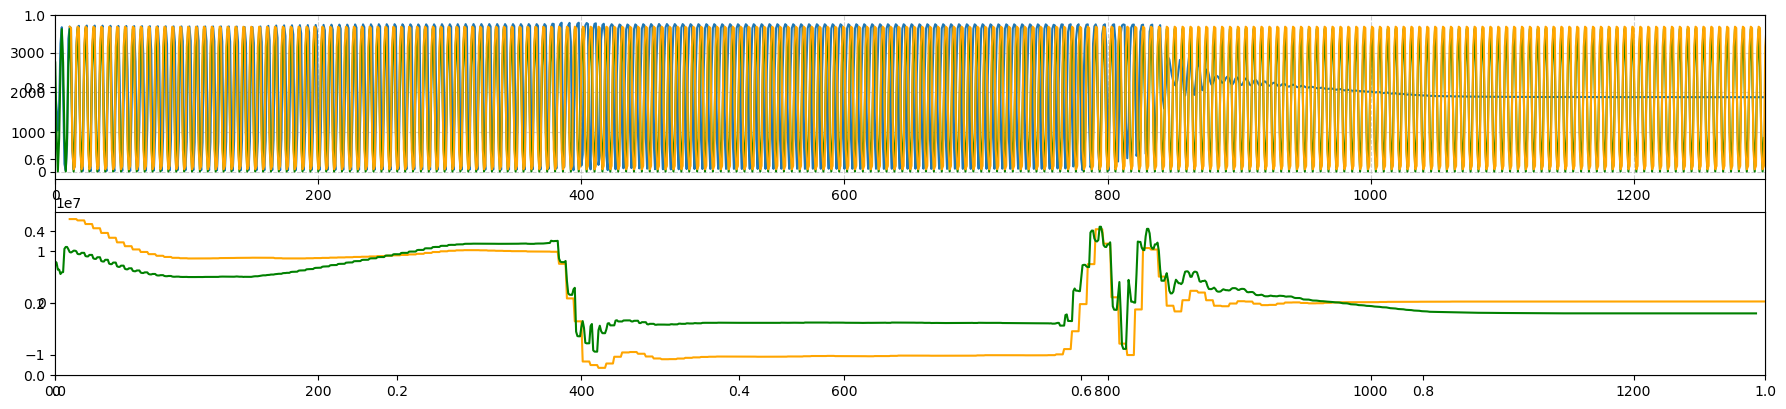

In [8]:
import numpy as np
import matplotlib.pyplot as plt
signal_type=["1010 squarewave",
    "Frequency x2",
    "Frequency x4",
    "Frequency x8",
    "pwm low",
    "pwm high",
    "Phase shift up",
    "Phase shift down",
    "Phase+Frequency"]
fig, ax = plt.subplots(figsize=(18, 4))
plt.subplots_adjust(left=0.04,right=0.99,bottom=0.1,top=1) # Make room for the button

filename = "air_Phase shift up.npy"
y_data = np.load(filename)
N_plot = 1300
ax=plt.subplot(2,1,1)
ax.set_xlim([0,N_plot])
plt.plot(y_data[:N_plot])

# reconstruct template from frequency
N=N_plot
timer_cycle=52./72e6
total_time=(N-1)*timer_cycle
f_sonar=230769.23
N_sonar_cycle=total_time*f_sonar
phase0=3.7
x0=np.linspace(0,N-1,N)
print(f_sonar*timer_cycle)
template=(np.sin(2*np.pi*f_sonar*timer_cycle*x0-phase0)+1)*1800
plt.plot(template,'g')
ax.grid(True, linestyle='--', alpha=0.6)

# sampling template from signal
phase=11
f=6
sample=y_data[phase:phase+f]
r=int(N/f)
y=np.tile(sample,r)
x=np.linspace(0,r*f-1,r*f)
plt.plot(x+phase,y,'orange')

ax=plt.subplot(2,1,2)
ax.set_xlim([0,N_plot])

# correlation 
sig_norm = (y_data - np.mean(y_data))
temp_norm = (sample - np.mean(y_data))
c=np.zeros(r)
for i in range(r):
    j=phase+i*f
    c[i] = np.correlate(sig_norm[j:j+f], temp_norm, mode='valid')[0]
correlation=np.repeat(c,f)
plt.plot(x+phase,correlation,'orange')

temp_norm = (template - np.mean(template))
correlation=np.zeros(N-f)
for i in range(N-f):
    correlation[i] = np.correlate(sig_norm[i:i+f], template[i:i+f], mode='valid')[0]
plt.plot(x0[:-f],correlation,'g')

plt.show()

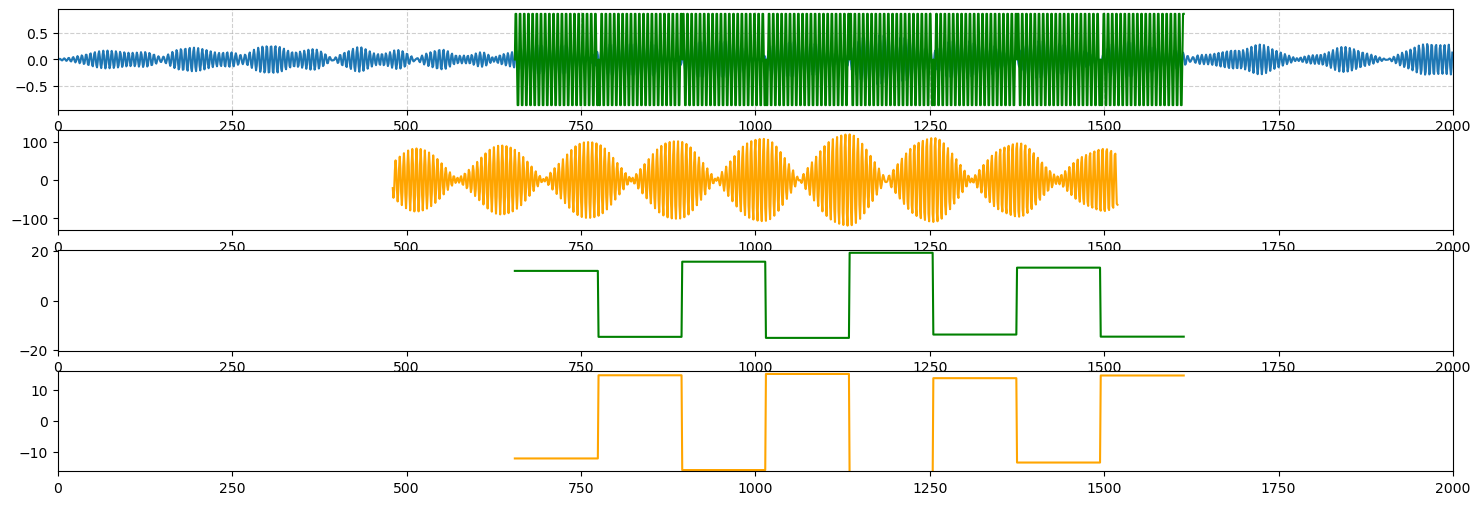

In [26]:
import numpy as np
import matplotlib.pyplot as plt
signal_type=["1010 squarewave",
    "Frequency x2",
    "Frequency x4",
    "Frequency x8",
    "pwm low",
    "pwm high",
    "Phase shift up",
    "Phase shift down",
    "Phase+Frequency"]
plt.figure(figsize=(18, 6))
#plt.subplots_adjust(left=0.04,right=0.99,bottom=0.1,top=1) # Make room for the button
amp=7
filename = "signal_test_1010 squarewave_tank_far.npy"
y_data = np.load(filename)
y_data = (y_data - np.mean(y_data))/max(y_data)

N_plot = 2000


# reconstruct template from frequency
cycle_per_digit=20
N_digits=8
N_window=cycle_per_digit*6
timer_cycle=52./72e6
f_sonar=230769.23
x0=np.linspace(0,N_plot-1,N_plot)
N_signal=cycle_per_digit*N_digits*6
t=np.linspace(0,N_window-1,N_window)
template1=np.sin(2*np.pi*f_sonar*timer_cycle*x0[:N_window])
template0=np.sin(2*np.pi*f_sonar*timer_cycle*x0[:N_window]+np.pi)
signal_template=np.zeros(N_signal)
for i in range(8):
    if(i%2==1):
        signal_template[i*N_window:i*N_window+N_window]=np.sin(2*np.pi*f_sonar*timer_cycle*t+np.pi)
    else:
        signal_template[i*N_window:i*N_window+N_window]=np.sin(2*np.pi*f_sonar*timer_cycle*t)


# correlation 
#sig_norm = (y_data - np.mean(y_data))
#temp_norm = (sample - np.mean(y_data))
ax=plt.subplot(4,1,2)
ax.set_xlim([0,N_plot])
correlation=np.zeros(N_plot-N_signal)
for i in range(N_plot-N_signal):
    correlation[i] = np.correlate(y_data[i:i+N_signal], signal_template, mode='valid')[0]
plt.plot(x0[int(N_signal/2):-int(N_signal/2)],correlation,'orange')
if(0):
    phase_shift=np.argmax(correlation)%N_window
    N_c=int((N_plot-phase_shift)/N_window)
else:
    phase_shift=np.argmax(correlation)
    N_c=8


ax=plt.subplot(4,1,1)
ax.set_xlim([0,N_plot])
plt.plot(y_data[:N_plot])
plt.plot(x0[phase_shift:phase_shift+N_window*8],signal_template,'g')
ax.grid(True, linestyle='--', alpha=0.6)


ax=plt.subplot(4,1,3)
ax.set_xlim([0,N_plot])

N_left=N_plot-phase_shift-N_c*N_window
correlation=np.zeros(N_c)
for i in range(N_c):
    correlation[i] = np.correlate(y_data[i*N_window+phase_shift:i*N_window+phase_shift+N_window], template1, mode='valid')[0]
signal_level=np.repeat(correlation,N_window)
plt.plot(x0[phase_shift:phase_shift+N_window*N_c],signal_level,'g')
amp=max(signal_level)+1
ax.set_ylim([-amp,amp])
ax=plt.subplot(4,1,4)
ax.set_xlim([0,N_plot])

for i in range(N_c):
    correlation[i] = np.correlate(y_data[i*N_window+phase_shift:i*N_window+phase_shift+N_window], template0, mode='valid')[0]
signal_level=np.repeat(correlation,N_window)
plt.plot(x0[phase_shift:phase_shift+N_window*N_c],signal_level,'orange')
amp=max(signal_level)+1
ax.set_ylim([-amp,amp])
plt.show()